In [41]:

library(DBI)
library(RPostgres)
library(tidyverse)
library(ggplot2)

con <- dbConnect(
  RPostgres::Postgres(),
  dbname = "statistics",
  host = "localhost",
  port = 5432,
  user = "postgres",
  password = "Magloire1987@"
)

cat("Connected to PostgreSQL!\n")

Connected to PostgreSQL!


In [43]:
library(readr)
cardio <- read_csv(
  "C:/Users/allad/Documents/GitHub/StatisticsProjects/data/CardioGoodFitness.csv"
)

Rows: 180 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): Product, Gender, MaritalStatus
dbl (6): Age, Education, Usage, Fitness, Income, Miles

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [50]:
library(janitor)
cardio <- cardio |>
  clean_names()
## -------------------------------------
dbWriteTable(
  con,
  "cardio_good_fitness",
  cardio,
  overwrite = TRUE
)

In [56]:
dbGetQuery(con,
           "SELECT * FROM cardio_good_fitness LIMIT 10")

product,age,gender,education,marital_status,usage,fitness,income,miles
<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
TM195,18,Male,14,Single,3,4,29562,112
TM195,19,Male,15,Single,2,3,31836,75
TM195,19,Female,14,Partnered,4,3,30699,66
TM195,19,Male,12,Single,3,3,32973,85
TM195,20,Male,13,Partnered,4,2,35247,47
TM195,20,Female,14,Partnered,3,3,32973,66
TM195,21,Female,14,Partnered,3,3,35247,75
TM195,21,Male,13,Single,3,3,32973,85
TM195,21,Male,15,Single,5,4,35247,141


In [61]:
dbGetQuery(
  con,
  "
SELECT product,
       COUNT(*) AS customers
FROM cardio_good_fitness
GROUP BY product
"
)

product,customers
<chr>,<int64>
TM798,40
TM498,60
TM195,80


In [65]:
dbGetQuery(
  con,
  "
SELECT Product,
       AVG(Income) AS average_income
FROM cardio_good_fitness
GROUP BY Product
"
)

product,average_income
<chr>,<dbl>
TM798,75441.57
TM498,48973.65
TM195,46418.03


In [70]:
dbGetQuery(
  con,
  "
SELECT count(*) AS female_customers
FROM cardio_good_fitness
WHERE Gender='Female'
"
)

female_customers
<int64>
76


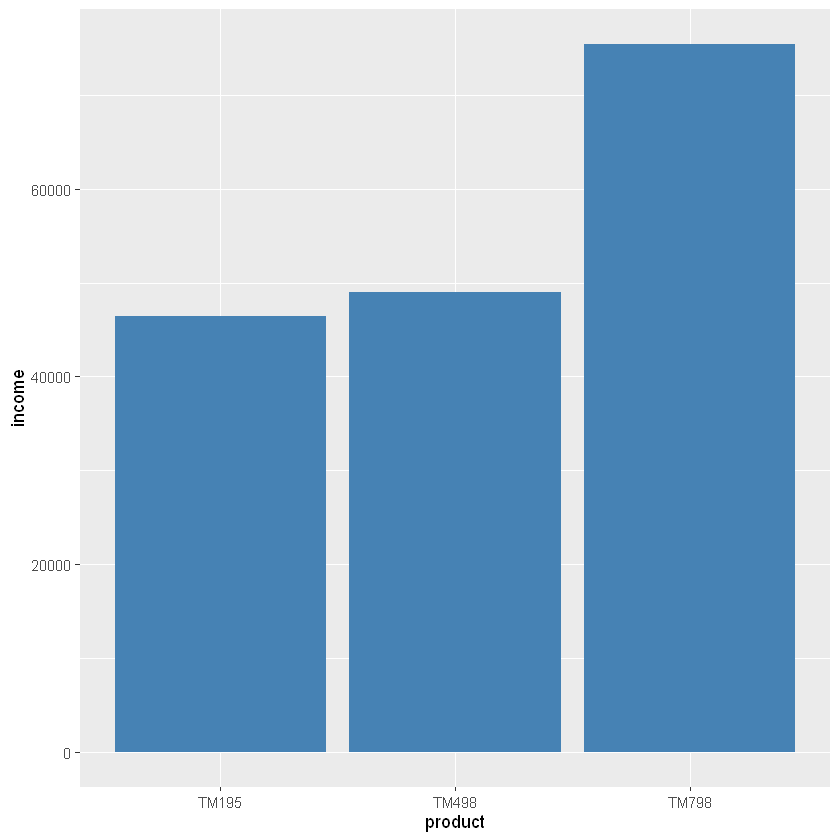

In [72]:

# Query only the data you need
income <- dbGetQuery(
  con,
  "
  SELECT product,
         AVG(income) AS income
  FROM cardio_good_fitness
  GROUP BY product
  "
)
#------------------------------
# Analyze and visualize in R
ggplot(income, aes(product, income)) +
  geom_col(fill = "steelblue")